# Bank Fraud Analysis: Identifying High-Risk Transaction Patterns
### Exploratory Data Analysis & Feature Engineering
**Author:** Marcus Rauls
**Goal:** To Identify key indicators of fraudulent activity in financial transactions

In [1]:
import pandas as pd
# This tells Python: "Find the CSV file next to me and load"
df = pd.read_csv('paysim_fraud_data.csv')

# This shows you the first 5 rows so you can see it worked
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
# 1. See how many rows of data we have
print(f"Total Transaction: {len(df)}")

# 2. See the different types of transaction (Payment, Transfer, etc.)
print("\nTransaction Type Breakdown:")
print(df['type'].value_counts())

# 3. See how many are actually flagged as fraud
print("\nFradulent vs. Legitamate:")
print(df['isFraud'].value_counts())


Total Transaction: 6362620

Transaction Type Breakdown:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fradulent vs. Legitamate:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [3]:
# Check for missing values in every column
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [4]:
# Compare the average transaction amount for Fraud vs. Legitimate
print("Average Transaction Amount:")
print(df.groupby('isFraud')['amount'].mean())

# Look at the maximum transaction for each category
print("\nMaximum Transaction Amount:")
print(df.groupby('isFraud')['amount'].max())

Average Transaction Amount:
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

Maximum Transaction Amount:
isFraud
0    92445516.64
1    10000000.00
Name: amount, dtype: float64


In [5]:
# Create a dataframe with only the transaction types where fraud actually occures
high_risk_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

# Verify the result by checking the new counts
print(f"Total High-Risk Transaction: {len(high_risk_df)}")
print(high_risk_df['type'].value_counts())
                            

Total High-Risk Transaction: 2770409
type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


In [6]:
# Create a feature that flag transactions that empty the account
high_risk_df['is_emptying_account'] = (high_risk_df['amount'] == high_risk_df['oldbalanceOrg']).astype(int)

# Create a feature for balance discrepancies
high_risk_df['balance_error_orig'] = high_risk_df['newbalanceOrig'] + high_risk_df['amount'] - high_risk_df['oldbalanceOrg']

# Create the correlation matrix first
corr_matrix = high_risk_df[['isFraud', 'is_emptying_account', 'balance_error_orig']].corr()

# Then print just the column you need
print(corr_matrix['isFraud'])

isFraud                1.000000
is_emptying_account    0.989011
balance_error_orig    -0.017149
Name: isFraud, dtype: float64


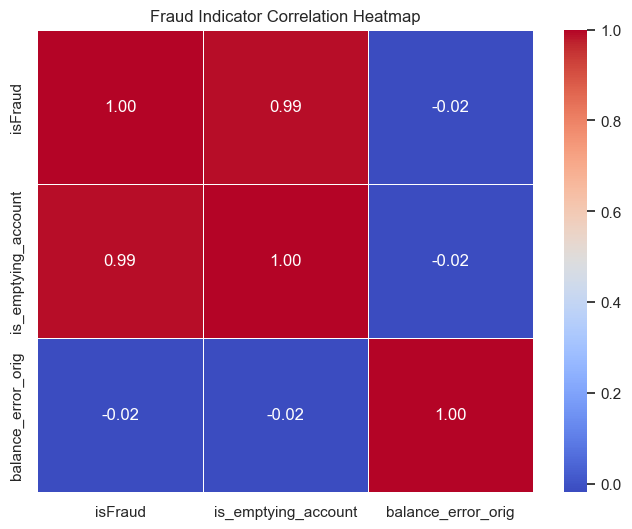

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


# Set the style
sns.set_theme(style="white")

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Fraud Indicator Correlation Heatmap')
plt.show()